# Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

from clean_data import clean_data, reshape_raw_bargaining_data, equilibrium_payoff, plot_bargaining_rounds

# Clean Data

In [2]:
df = pd.read_csv("/Users/nicolasroever/Dropbox/Promotion/Bargaining/bargaining_experiment_analysis/src/bargaining_analysis/data/Data_Collection_03_04_2025/raw_data.csv")


In [3]:
df_clean = clean_data(df)
df_clean.shape

/Users/nicolasroever/Dropbox/Promotion/Bargaining/bargaining_experiment_analysis/src/bargaining_analysis/analysis_03042025/clean_data.py:268: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df


(240, 43)

# Seller Gains from Trade

In [10]:
df_clean_seller = df_clean[(df_clean["participant_role"] == "Seller")]

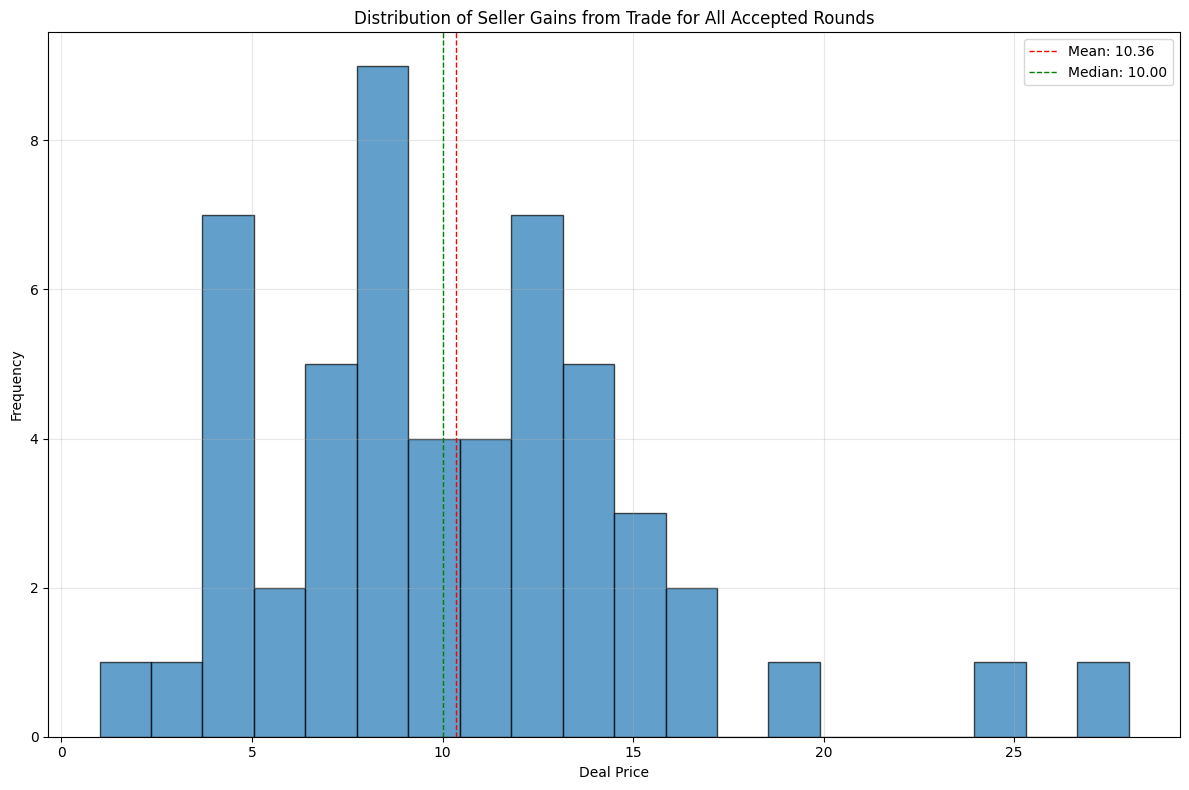

Number of deals: 53
Mean deal price: 10.36
Median deal price: 10.00
Minimum deal price: 1.00
Maximum deal price: 28.00
Standard deviation: 5.14


In [11]:
# Create the histogram
plt.figure(figsize=(12, 8))

# Plot the histogram
plt.hist(df_clean_seller['deal_price'].dropna(), bins=20, edgecolor='black', alpha=0.7)

# Add labels and title
plt.title('Distribution of Seller Gains from Trade for All Accepted Rounds')
plt.xlabel('Deal Price')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

# Add statistics
mean_price = df_clean_seller['deal_price'].mean()
median_price = df_clean_seller['deal_price'].median()
plt.axvline(mean_price, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {mean_price:.2f}')
plt.axvline(median_price, color='green', linestyle='dashed', linewidth=1, label=f'Median: {median_price:.2f}')

# Add legend
plt.legend()

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

# Print some statistics
print(f"Number of deals: {df_clean_seller['deal_price'].count()}")
print(f"Mean deal price: {mean_price:.2f}")
print(f"Median deal price: {median_price:.2f}")
print(f"Minimum deal price: {df_clean_seller['deal_price'].min():.2f}")
print(f"Maximum deal price: {df_clean_seller['deal_price'].max():.2f}")
print(f"Standard deviation: {df_clean_seller['deal_price'].std():.2f}")

In [12]:
# Convert deal_price to numeric, coercing errors to NaN
deal_prices = pd.to_numeric(df_clean['deal_price'], errors='coerce')

# Drop any remaining NaN values
deal_prices = deal_prices.dropna()

# Perform one-sided t-test
t_stat, p_value = stats.ttest_1samp(deal_prices, popmean=0)

# Since we're testing if mean > 0, we need to divide p-value by 2 for one-sided test
p_value_one_sided = p_value / 2

In [13]:
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value (one-sided): {p_value_one_sided:.4f}")
print(f"Sample size: {len(deal_prices)}")
print(f"Sample mean: {deal_prices.mean():.4f}")
print(f"Sample standard deviation: {deal_prices.std():.4f}")


T-statistic: 20.8300
P-value (one-sided): 0.0000
Sample size: 106
Sample mean: 10.3585
Sample standard deviation: 5.1199


# Low Valuation Prediction

In [14]:
df_buyers = df_clean[(df_clean["participant_role"] == "Buyer")]

In [15]:
# Generate x values for the theoretical line
x_values = np.linspace(0, 30, 1000)
y_values = [equilibrium_payoff(x) for x in x_values]

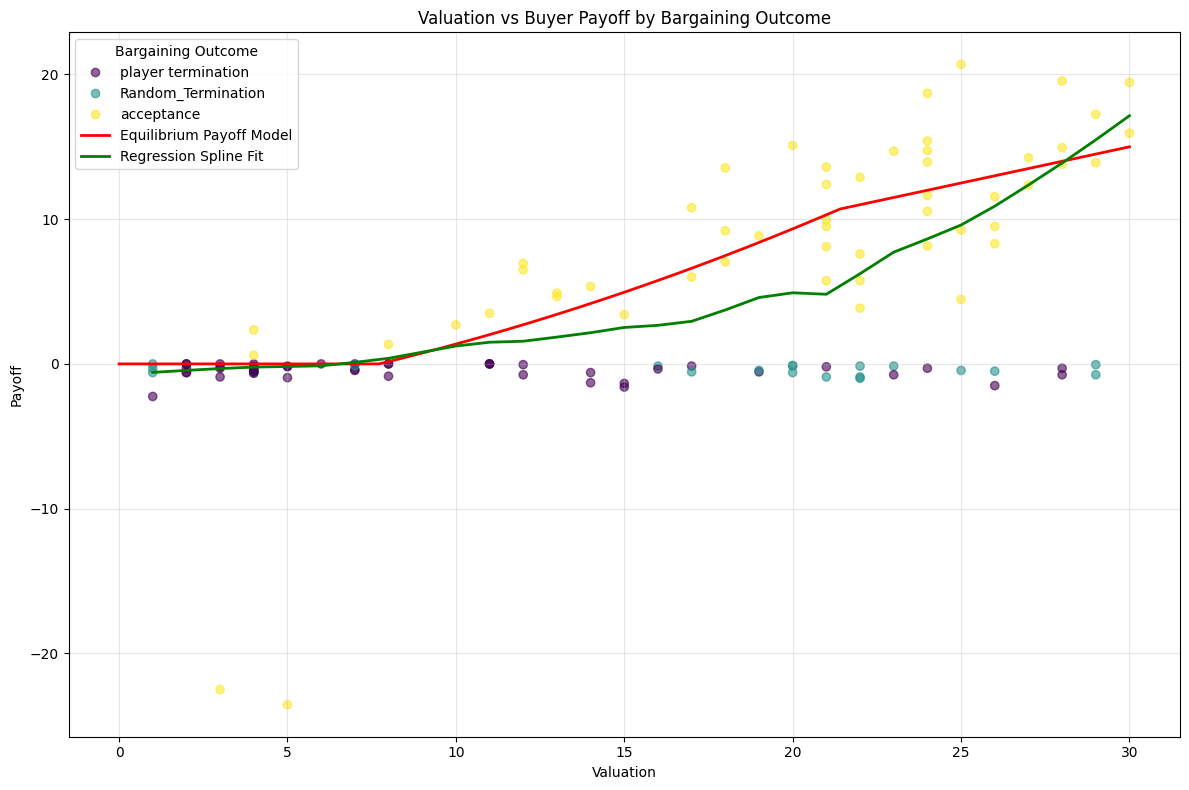

In [16]:
plt.figure(figsize=(12, 8))

# Plot the theoretical line
plt.plot(x_values, y_values, 'r-', linewidth=2, label='Theoretical Payoff')

# Add the scatter plot
scatter = plt.scatter(
    df_buyers['valuation'],
    df_buyers['payoff'],
    c=pd.Categorical(df_buyers['bargaining_outcome']).codes,
    cmap='viridis',
    alpha=0.6
)

# Add LOWESS line
lowess = sm.nonparametric.lowess(df_buyers['payoff'], df_buyers['valuation'], frac=0.3)
plt.plot(lowess[:, 0], lowess[:, 1], 'g-', linewidth=2, label='LOWESS Fit')

plt.title('Valuation vs Buyer Payoff by Bargaining Outcome')
plt.xlabel('Valuation')
plt.ylabel('Payoff')
plt.grid(True, alpha=0.3)

# Create legend
handles, _ = scatter.legend_elements(prop="colors", alpha=0.6)
labels = pd.Categorical(df_buyers['bargaining_outcome']).categories
# Update 'Player' to 'player termination' in labels
labels = ['player termination' if label == 'Player' else label for label in labels]
plt.legend(handles + [plt.Line2D([0], [0], color='red', linewidth=2), plt.Line2D([0], [0], color='green', linewidth=2)], 
          list(labels) + ['Equilibrium Payoff Model', 'Regression Spline Fit'], 
          title="Bargaining Outcome")

plt.tight_layout()
plt.show()

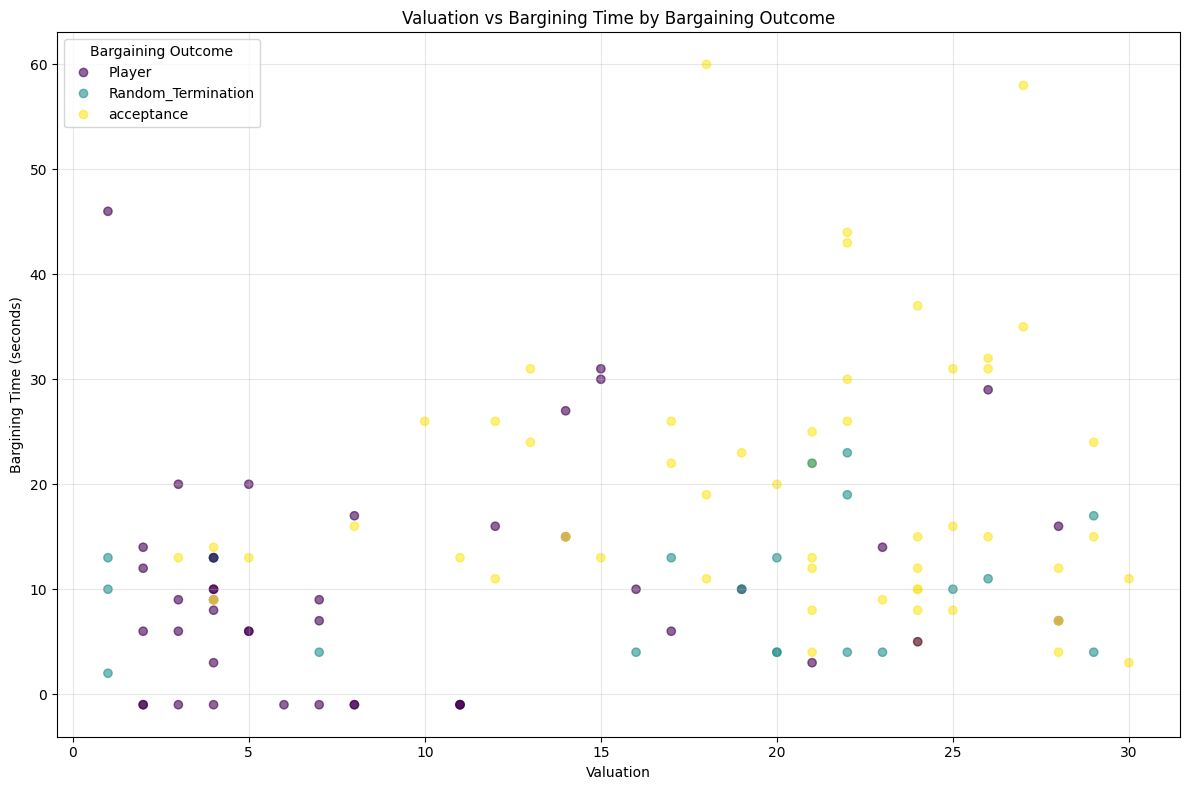

In [17]:
df_plot = df_buyers[df_buyers["bargaining_duration_sec"] < 200]
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    df_plot['valuation'],
    df_plot['bargaining_duration_sec'],
    c=pd.Categorical(df_plot['bargaining_outcome']).codes,
    cmap='viridis',
    alpha=0.6
)

plt.title('Valuation vs Bargining Time by Bargaining Outcome')
plt.xlabel('Valuation')
plt.ylabel('Bargining Time (seconds)')
plt.grid(True, alpha=0.3)


# auto‐generate legend entries from the scatter
handles, _ = scatter.legend_elements(prop="colors", alpha=0.6)
labels = pd.Categorical(df_buyers['bargaining_outcome']).categories
plt.legend(handles, labels, title="Bargaining Outcome")

plt.tight_layout()
plt.show()


In [18]:
df_filter = df_clean[(df_clean["valuation"] == 4 )& (pd.isna(df_clean["termination_mode"]))]

# visualize bargains

/Users/nicolasroever/Dropbox/Promotion/Bargaining/bargaining_experiment_analysis/src/bargaining_analysis/analysis_03042025/clean_data.py:385: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


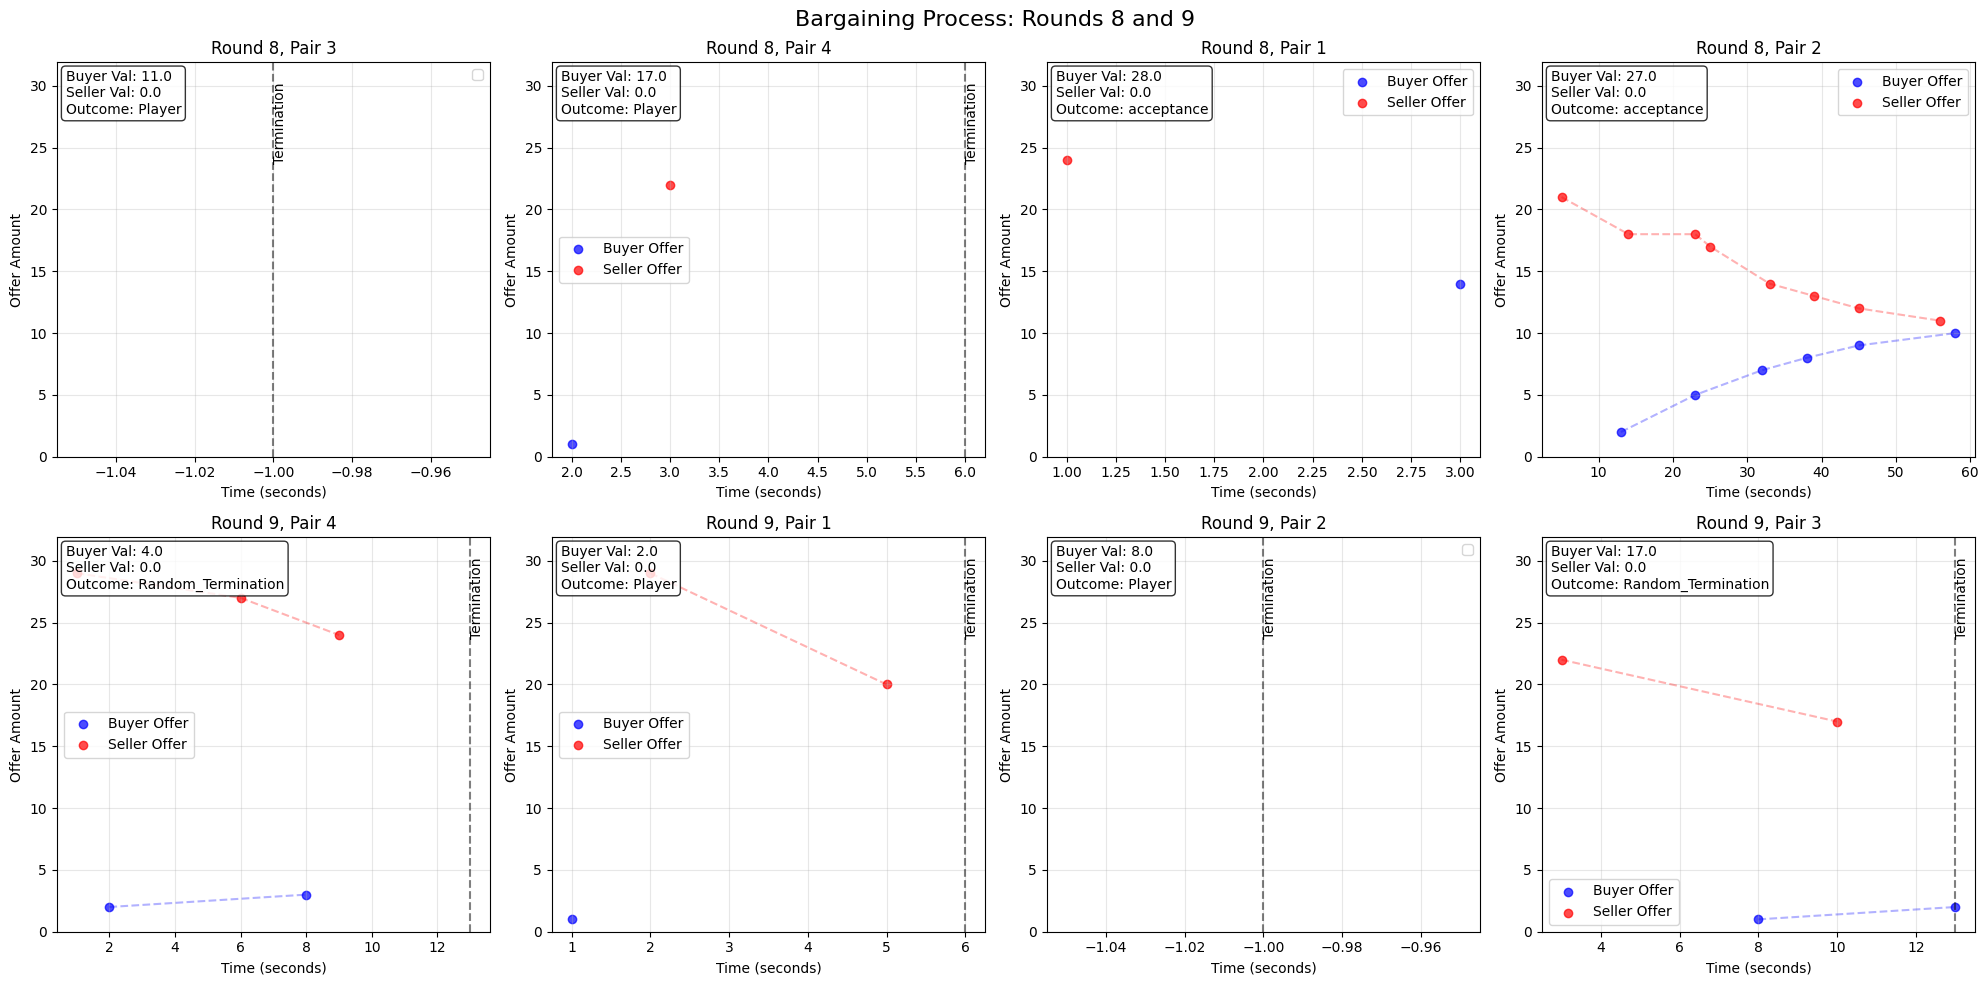

In [19]:
# Example usage:
plot_bargaining_rounds(df_clean, 8,9)  # For rounds 4 and 5

# Number of Offers

In [20]:
df_buyers = df_clean[(df_clean["participant_role"] == "Buyer")]

/var/folders/f_/lhmm20kd6r979skh60tngks80000gn/T/ipykernel_74369/2443579118.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


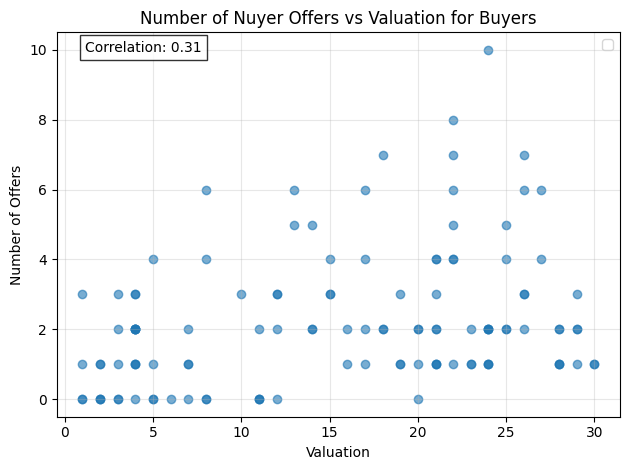

In [21]:
# Create scatter plot
plt.scatter(
    df_buyers['valuation'],
    df_buyers['number_of_offers'],
    alpha=0.6
)

# Add labels and title
plt.title('Number of Nuyer Offers vs Valuation for Buyers')
plt.xlabel('Valuation')
plt.ylabel('Number of Offers')
plt.grid(True, alpha=0.3)

# Calculate and display correlation
correlation = df_buyers['valuation'].corr(df_buyers['number_of_offers'])
plt.text(0.05, 0.95, f'Correlation: {correlation:.2f}', 
         transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.8))

# Add legend
plt.legend()

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

/var/folders/f_/lhmm20kd6r979skh60tngks80000gn/T/ipykernel_74369/3666510550.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


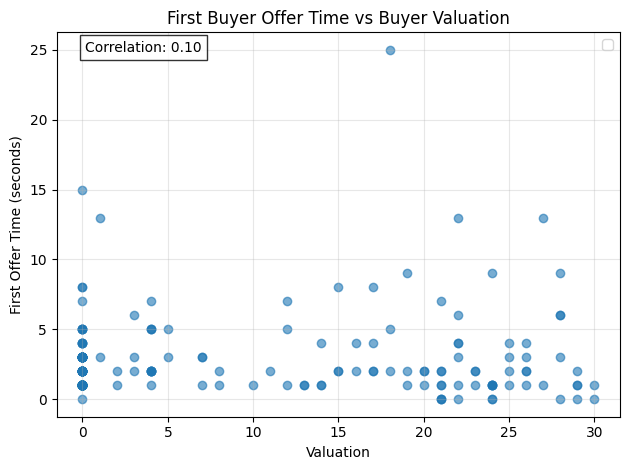

In [22]:

# Create scatter plot
plt.scatter(
    df_clean['valuation'],
    df_clean['offer_time_1'],
    alpha=0.6
)

# Add labels and title
plt.title('First Buyer Offer Time vs Buyer Valuation')
plt.xlabel('Valuation')
plt.ylabel('First Offer Time (seconds)')
plt.grid(True, alpha=0.3)

# Calculate and display correlation
correlation = df_clean['valuation'].corr(df_clean['offer_time_1'])
plt.text(0.05, 0.95, f'Correlation: {correlation:.2f}', 
         transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.8))

# Add legend
plt.legend()

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()


# Beahvioural Theory: The richer I am, the more bullish I can be

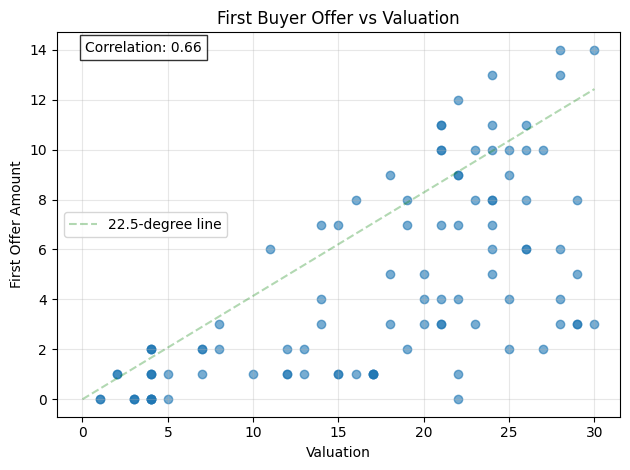

In [23]:


# Create scatter plot
plt.scatter(
    df_buyers['valuation'],
    df_buyers['offer_1'],
    alpha=0.6
)

# Add labels and title
plt.title('First Buyer Offer vs Valuation')
plt.xlabel('Valuation')
plt.ylabel('First Offer Amount')
plt.grid(True, alpha=0.3)

# Calculate and display correlation
correlation = df_buyers['valuation'].corr(df_buyers['offer_1'])
plt.text(0.05, 0.95, f'Correlation: {correlation:.2f}', 
         transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.8))

# Add a 45-degree reference line
max_val = max(df_buyers['valuation'].max(), df_buyers['offer_1'].max())
plt.plot([0, max_val], [0, max_val * np.tan(np.radians(22.5))], 'g--', alpha=0.3, label='22.5-degree line')

# Add legend
plt.legend()

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()


/var/folders/f_/lhmm20kd6r979skh60tngks80000gn/T/ipykernel_74369/3596293570.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


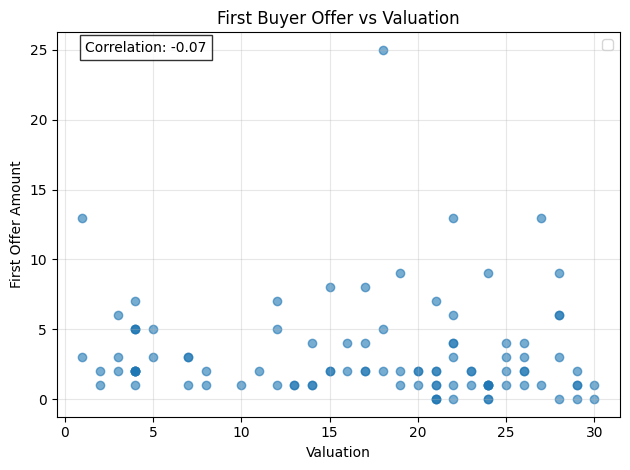

In [24]:
# Create scatter plot
plt.scatter(
    df_buyers['valuation'],
    df_buyers['offer_time_1'],
    alpha=0.6
)

# Add labels and title
plt.title('First Buyer Offer vs Valuation')
plt.xlabel('Valuation')
plt.ylabel('First Offer Amount')
plt.grid(True, alpha=0.3)

# Calculate and display correlation
correlation = df_buyers['valuation'].corr(df_buyers['offer_time_1'])
plt.text(0.05, 0.95, f'Correlation: {correlation:.2f}', 
         transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.8))


# Add legend
plt.legend()

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()


# Terminations

In [25]:
terminations = df_clean['termination_mode'].value_counts()
terminations

termination_mode
Player                90
Random_Termination    44
Name: count, dtype: int64

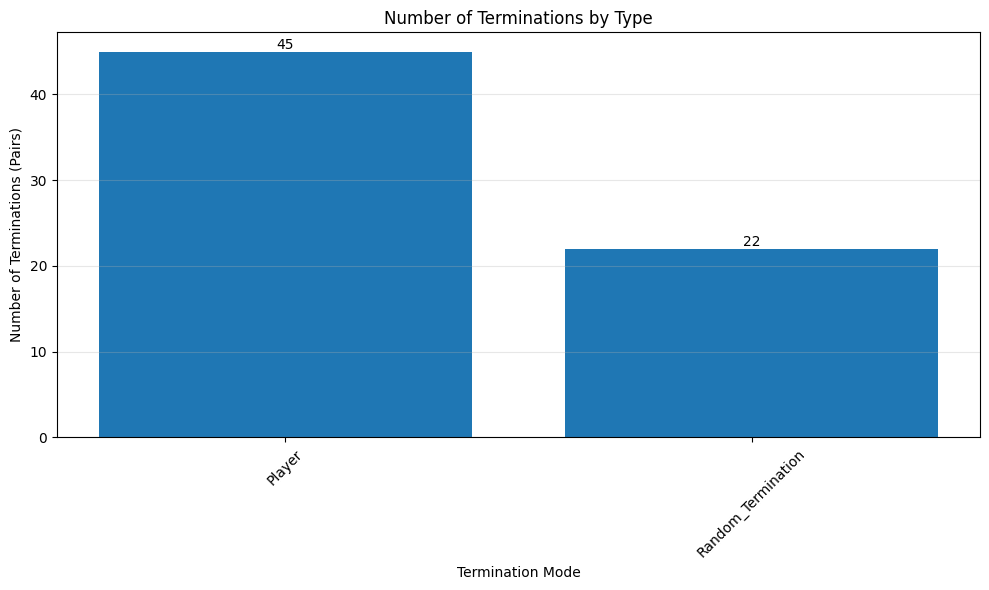

In [26]:
# Create the barplot
plt.figure(figsize=(10, 6))

# Get termination counts and divide by 2
termination_counts = df_clean['termination_mode'].value_counts() / 2

# Create the barplot
bars = plt.bar(termination_counts.index, termination_counts.values)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.0f}',
             ha='center', va='bottom')

# Customize the plot
plt.title('Number of Terminations by Type')
plt.xlabel('Termination Mode')
plt.ylabel('Number of Terminations (Pairs)')
plt.grid(True, axis='y', alpha=0.3)

# Rotate x-axis labels if needed
plt.xticks(rotation=45)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show the plot
plt.show()

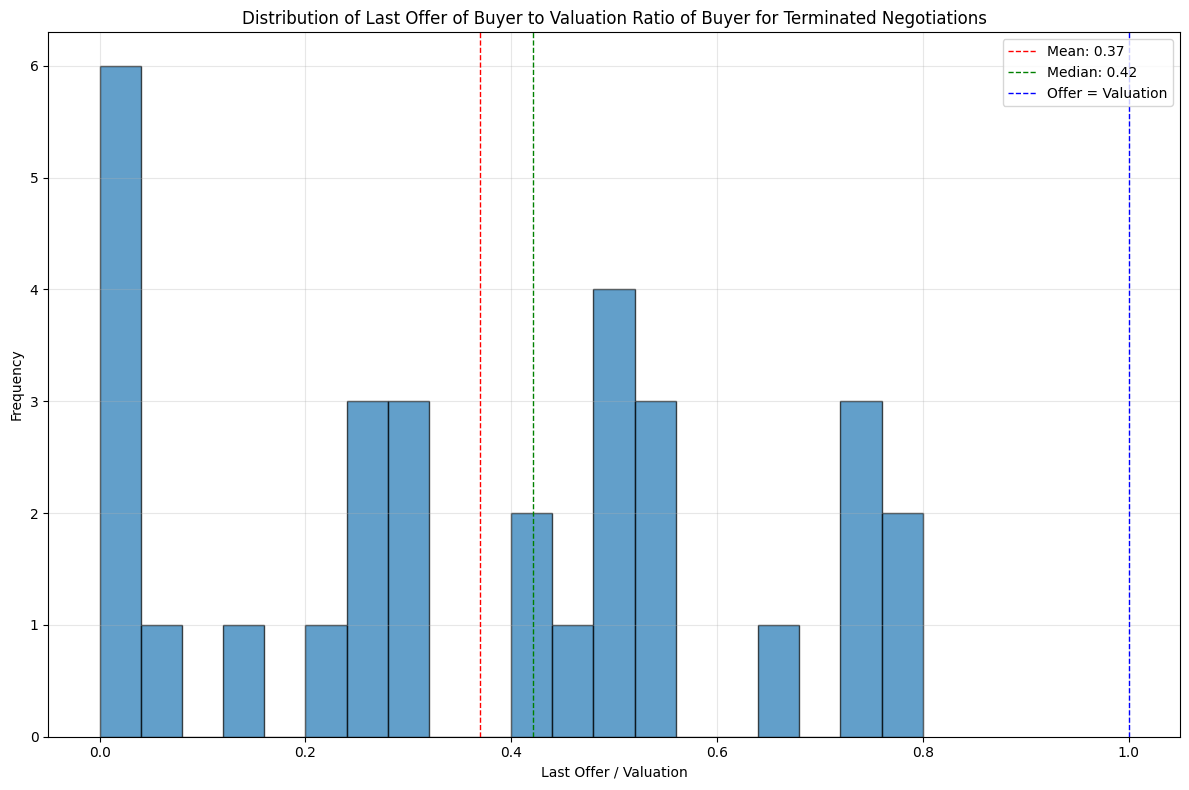

Number of terminated negotiations: 45
Mean ratio: 0.37
Median ratio: 0.42
Minimum ratio: 0.00
Maximum ratio: 0.80
Standard deviation: 0.26


In [27]:
terminations = df_clean[(df_clean["bargaining_outcome"] == "Player") & (df_clean["participant_role"] == "Buyer")]
# Calculate last offer for each negotiation
offer_cols = [f"offer_{i}" for i in range(1, 11)]
last_offer = (
    terminations[offer_cols]
    .ffill(axis=1)        # propagate last non-NA to the right
    .iloc[:, -1]          # grab that propagated value
)

# Calculate the ratio of last offer to valuation
offer_valuation_ratio = last_offer / terminations['valuation']

# Create the histogram
plt.figure(figsize=(12, 8))

# Plot the histogram
plt.hist(offer_valuation_ratio.dropna(), bins=20, edgecolor='black', alpha=0.7)

# Add labels and title
plt.title('Distribution of Last Offer of Buyer to Valuation Ratio of Buyer for Terminated Negotiations')
plt.xlabel('Last Offer / Valuation')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

# Add vertical lines for mean and median
mean_ratio = offer_valuation_ratio.mean()
median_ratio = offer_valuation_ratio.median()
plt.axvline(mean_ratio, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {mean_ratio:.2f}')
plt.axvline(median_ratio, color='green', linestyle='dashed', linewidth=1, label=f'Median: {median_ratio:.2f}')

# Add a vertical line at 1.0 (where offer equals valuation)
plt.axvline(1.0, color='blue', linestyle='dashed', linewidth=1, label='Offer = Valuation')

# Add legend
plt.legend()

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

# Print some statistics
print(f"Number of terminated negotiations: {len(offer_valuation_ratio)}")
print(f"Mean ratio: {mean_ratio:.2f}")
print(f"Median ratio: {median_ratio:.2f}")
print(f"Minimum ratio: {offer_valuation_ratio.min():.2f}")
print(f"Maximum ratio: {offer_valuation_ratio.max():.2f}")
print(f"Standard deviation: {offer_valuation_ratio.std():.2f}")

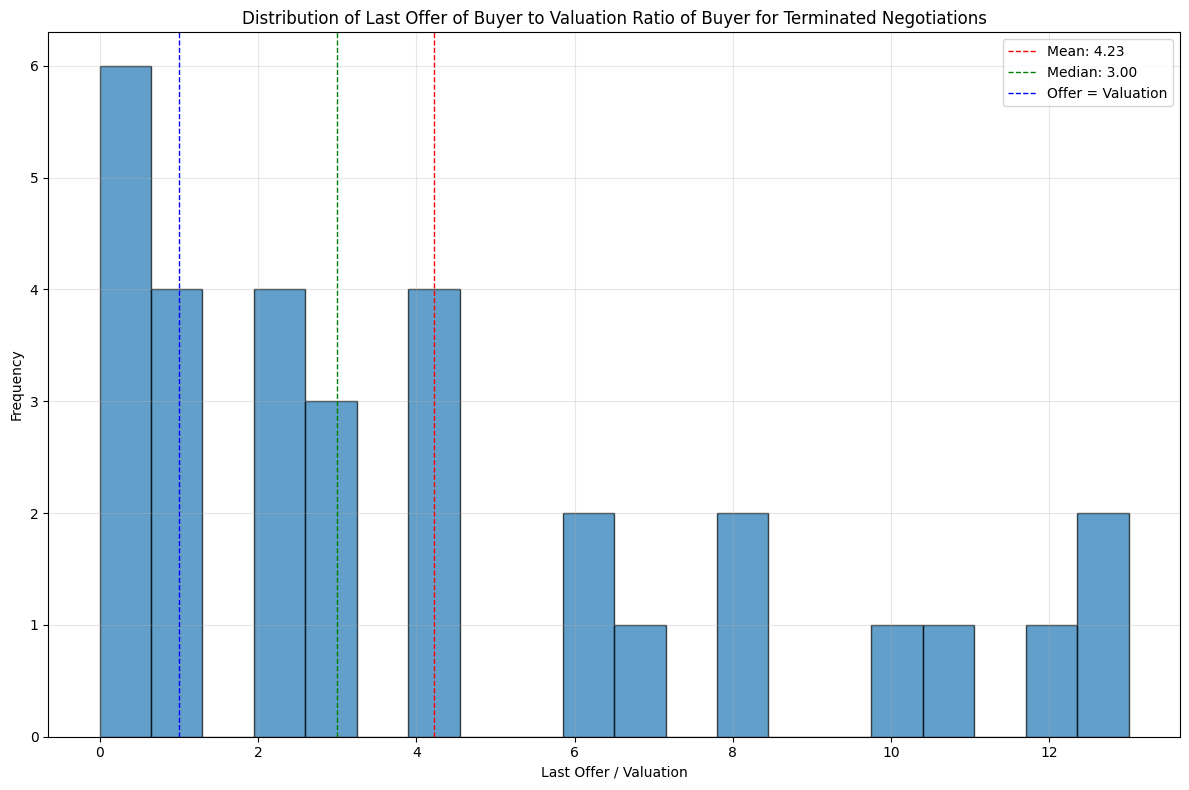

Number of terminated negotiations: 45
Mean ratio: 4.23
Median ratio: 3.00
Minimum ratio: 0.00
Maximum ratio: 13.00
Standard deviation: 4.12


In [28]:
terminations = df_clean[(df_clean["bargaining_outcome"] == "Player") & (df_clean["participant_role"] == "Buyer")]
# Calculate last offer for each negotiation
offer_cols = [f"offer_{i}" for i in range(1, 11)]
last_offer = (
    terminations[offer_cols]
    .ffill(axis=1)        # propagate last non-NA to the right
    .iloc[:, -1]          # grab that propagated value
)

# Calculate the ratio of last offer to valuation
offer_valuation_ratio = last_offer 

# Create the histogram
plt.figure(figsize=(12, 8))

# Plot the histogram
plt.hist(offer_valuation_ratio.dropna(), bins=20, edgecolor='black', alpha=0.7)

# Add labels and title
plt.title('Distribution of Last Offer of Buyer to Valuation Ratio of Buyer for Terminated Negotiations')
plt.xlabel('Last Offer / Valuation')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

# Add vertical lines for mean and median
mean_ratio = offer_valuation_ratio.mean()
median_ratio = offer_valuation_ratio.median()
plt.axvline(mean_ratio, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {mean_ratio:.2f}')
plt.axvline(median_ratio, color='green', linestyle='dashed', linewidth=1, label=f'Median: {median_ratio:.2f}')

# Add a vertical line at 1.0 (where offer equals valuation)
plt.axvline(1.0, color='blue', linestyle='dashed', linewidth=1, label='Offer = Valuation')

# Add legend
plt.legend()

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

# Print some statistics
print(f"Number of terminated negotiations: {len(offer_valuation_ratio)}")
print(f"Mean ratio: {mean_ratio:.2f}")
print(f"Median ratio: {median_ratio:.2f}")
print(f"Minimum ratio: {offer_valuation_ratio.min():.2f}")
print(f"Maximum ratio: {offer_valuation_ratio.max():.2f}")
print(f"Standard deviation: {offer_valuation_ratio.std():.2f}")

## Who Gets the Gains From Trade?

In [29]:
df_accepted_buyers = df_clean[(df_clean["deal_price"].notna()) & (df_clean["participant_role"] == "Buyer")]
df_accepted_buyers.shape

(53, 43)

In [30]:
df_accepted_buyers["gains_from_trade_share_buyer_valuation"] = df_accepted_buyers["deal_price"] / df_accepted_buyers["valuation"]

/var/folders/f_/lhmm20kd6r979skh60tngks80000gn/T/ipykernel_74369/1872955012.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_accepted_buyers["gains_from_trade_share_buyer_valuation"] = df_accepted_buyers["deal_price"] / df_accepted_buyers["valuation"]


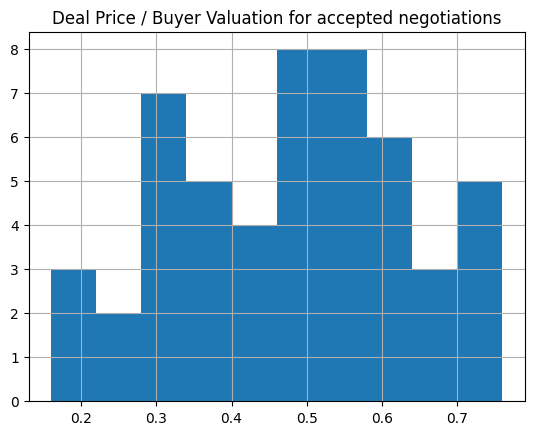

In [31]:
df_accepted_buyers = df_accepted_buyers[df_accepted_buyers["gains_from_trade_share_buyer_valuation"] < 1]
df_accepted_buyers["gains_from_trade_share_buyer_valuation"].describe()
df_accepted_buyers["gains_from_trade_share_buyer_valuation"].hist()
plt.title('Deal Price / Buyer Valuation for accepted negotiations')
plt.show()

# Who made the initial offer?

In [32]:
df_accepted = df_clean[df_clean["deal_price"].notna()]


In [33]:
pd.crosstab(df_accepted["first_offer"], df_accepted["participant_role"])

participant_role,Buyer,Seller
first_offer,,
0,28,25
1,25,28


In [34]:
pd.crosstab(df_clean["first_offer"], df_clean["participant_role"])

participant_role,Buyer,Seller
first_offer,,
0,64,43
1,43,64


# Distribution of Buyer Offer

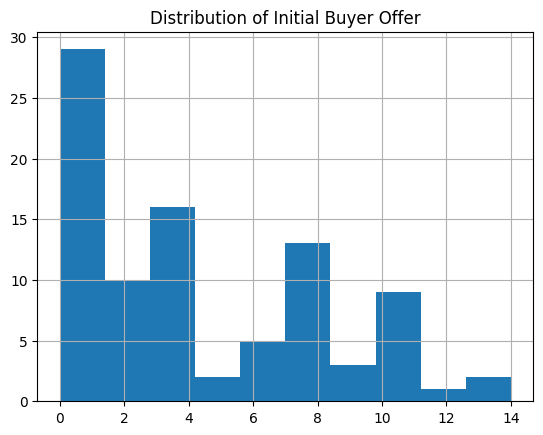

In [35]:
df_buyers = df_clean[(df_clean["participant_role"] == "Buyer") & (df_clean["bargaining_duration_sec"] > 4)]
df_buyers["offer_1"].describe()
df_buyers["offer_1"].hist()
plt.title("Distribution of Initial Buyer Offer")
plt.show()



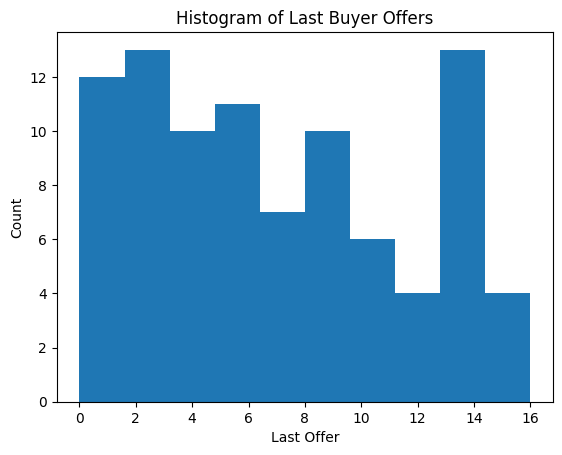

In [36]:
import matplotlib.pyplot as plt

# select your offer columns in order
offer_cols = [f"offer_{i}" for i in range(1, 11)]

# forward‑fill along each row, then take the very last column’s value
last_offer = (
    df_buyers[offer_cols]
    .ffill(axis=1)        # propagate last non‑NA to the right
    .iloc[:, -1]          # grab that propagated value
)

# drop any rows that were all-NA
last_offer = last_offer.dropna()

# plot histogram
plt.figure()
plt.hist(last_offer)
plt.xlabel("Last Offer")
plt.ylabel("Count")
plt.title("Histogram of Last Buyer Offers")
plt.show()


/var/folders/f_/lhmm20kd6r979skh60tngks80000gn/T/ipykernel_74369/664157562.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_buyers['offer_1_share_valuation'] = df_buyers['offer_1'] / df_buyers['valuation']


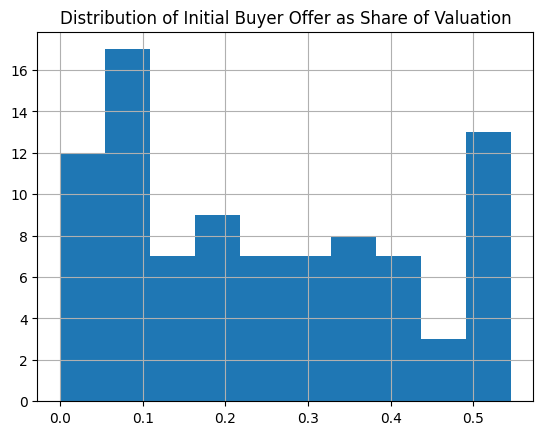

In [37]:
df_buyers['offer_1_share_valuation'] = df_buyers['offer_1'] / df_buyers['valuation']
df_buyers['offer_1_share_valuation'].describe()
df_buyers['offer_1_share_valuation'].hist()
plt.title("Distribution of Initial Buyer Offer as Share of Valuation")
plt.show()



# Relationship between buyer valuation and bargaining outcome

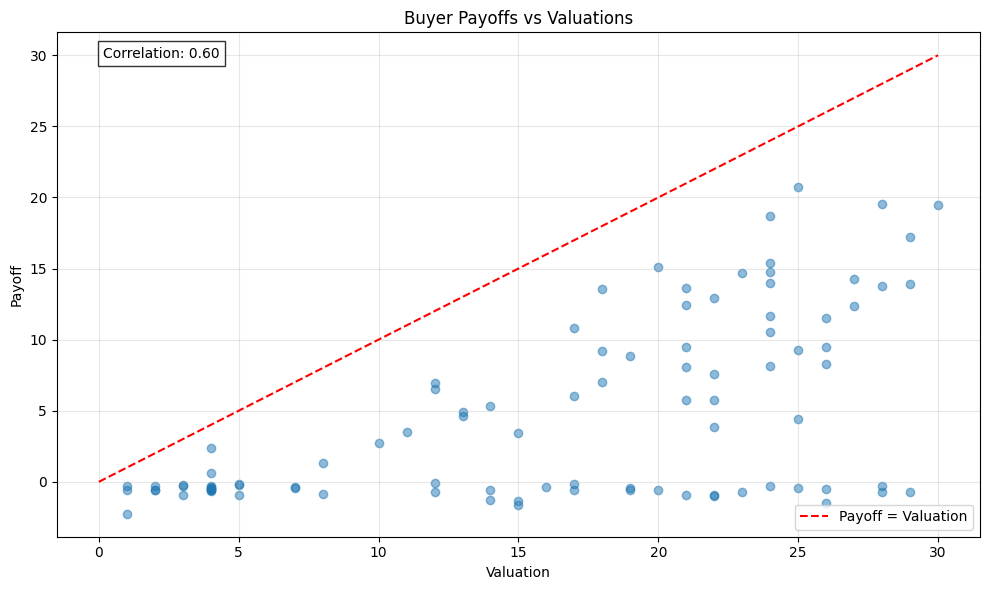

In [38]:
df_buyers_plot = df_buyers[df_buyers["payoff"] > -10]
# Create the scatterplot
plt.figure(figsize=(10, 6))

# Create scatter plot
plt.scatter(df_buyers_plot['valuation'], df_buyers_plot['payoff'], alpha=0.5)

# Add a 45-degree line for reference (where payoff = valuation)
max_val = max(df_buyers['valuation'].max(), df_buyers['payoff'].max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Payoff = Valuation')

# Add labels and title
plt.title('Buyer Payoffs vs Valuations')
plt.xlabel('Valuation')
plt.ylabel('Payoff')
plt.grid(True, alpha=0.3)

# Add legend
plt.legend()

# Calculate and display correlation
correlation = df_buyers['valuation'].corr(df_buyers['payoff'])
plt.text(0.05, 0.95, f'Correlation: {correlation:.2f}', 
         transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.8))

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

In [39]:
pd.crosstab(df_buyers["valuation_bucket"], df_buyers["bargaining_outcome"])

bargaining_outcome,Player,Random_Termination,acceptance
valuation_bucket,,,
1-9,18,5,5
10-19,9,2,14
20+,5,7,31


/var/folders/f_/lhmm20kd6r979skh60tngks80000gn/T/ipykernel_74369/772282666.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


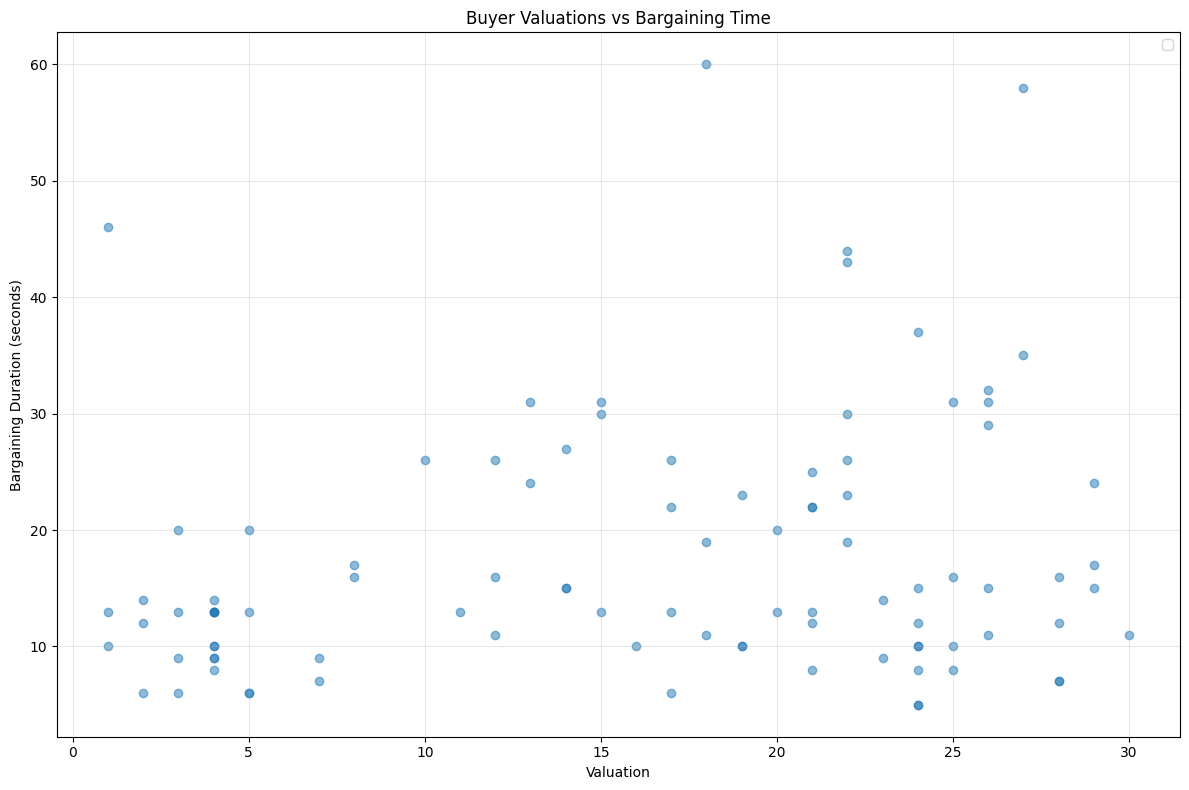

In [40]:
df_buyers_plot = df_buyers[df_buyers["bargaining_duration_sec"] < 200]
plt.figure(figsize=(12, 8))

# Create scatter plot
plt.scatter(df_buyers_plot['valuation'], df_buyers_plot['bargaining_duration_sec'], alpha=0.5)

# Add labels and title
plt.title('Buyer Valuations vs Bargaining Time')
plt.xlabel('Valuation')
plt.ylabel('Bargaining Duration (seconds)')
plt.grid(True, alpha=0.3)

# Add legend
plt.legend()

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()


In [45]:
errors = df_buyers[df_buyers["payoff"] < -10]

## Time

<Axes: >

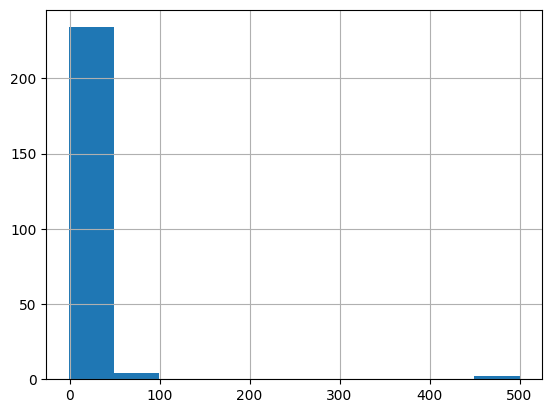

In [42]:
df_clean['bargaining_duration_sec'].hist()

In [44]:
errors = df_clean[df_clean["bargaining_duration_sec"] > 400] 